In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error

df=pd.read_csv("features_ready.csv")
feature_cols=[c for c in df.columns if c not in ['bandgap','formula','formation_energy']]
X=df[feature_cols].values
Y=df['bandgap'].values

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)
print(f"loaded {len(df)} materials instatnly")
print(f"X shape: {X.shape}")
print(f"RF baseline to beat: MAE =0.469ev")

loaded 19888 materials instatnly
X shape: (19888, 132)
RF baseline to beat: MAE =0.469ev


In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
from xgboost import XGBRegressor
xgb_default = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_default.fit(X_train,Y_train)
y_pred_xgb=xgb_default.predict(X_test)

mae_xgb = mean_absolute_error(Y_test,y_pred_xgb)
r2_xgb=xgb_default.score(X_test,Y_test)
print("default XGBoost")
print(f"MAE: {mae_xgb:.4f} ev")
print(f"R²:{r2_xgb:.4f}")
improvement =((0.469-mae_xgb) / 0.469) * 100
print(f"Improvement: {improvement:.1f}%")


default XGBoost
MAE: 0.3984 ev
R²:0.5865
Improvement: 15.1%


In [9]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[300,500],
    'learning_rate': [0.05,0.1],
    'max_depth': [4,6],
    'subsample': [0.8,1.0],
    'colsample_bytree':[0.7,0.9],
    'min_child_weight':[1,3]
}
print("Testingt combinations of hyperparameters")
xgb_grid =GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1,verbosity=0),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train,Y_train)
print("best parameters")
print(xgb_grid.best_params_)
print(f" Best CV MAE: {-xgb_grid.best_score_:.4f} ev")


Testingt combinations of hyperparameters
Fitting 3 folds for each of 64 candidates, totalling 192 fits
best parameters
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
 Best CV MAE: 0.3964 ev


In [10]:
best_params = xgb_grid.best_params_
xgb_best = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,verbosity=0)
cv_scores = cross_val_score(
    xgb_best,X,Y,cv=5,scoring='neg_mean_absolute_error',n_jobs=-1)
cv_mae=-cv_scores


print(f"=== TUNED XGBoost — 5-FOLD CV ===")
print(f"MAE per fold: {cv_mae.round(4)}")
print(f"\n>>> YOUR NEW RESULT: MAE = {cv_mae.mean():.3f} ± {cv_mae.std():.3f} eV <<<")
print(f"\nDay 4 RF was: 0.469 ± 0.011 eV")
print(f"Day 5 XGB is: {cv_mae.mean():.3f} ± {cv_mae.std():.3f} eV")
improvement = ((0.469 - cv_mae.mean()) / 0.469) * 100
print(f"Improvement: {improvement:.1f}%")

=== TUNED XGBoost — 5-FOLD CV ===
MAE per fold: [0.4632 0.456  0.4855 0.4658 0.4586]

>>> YOUR NEW RESULT: MAE = 0.466 ± 0.010 eV <<<

Day 4 RF was: 0.469 ± 0.011 eV
Day 5 XGB is: 0.466 ± 0.010 eV
Improvement: 0.7%


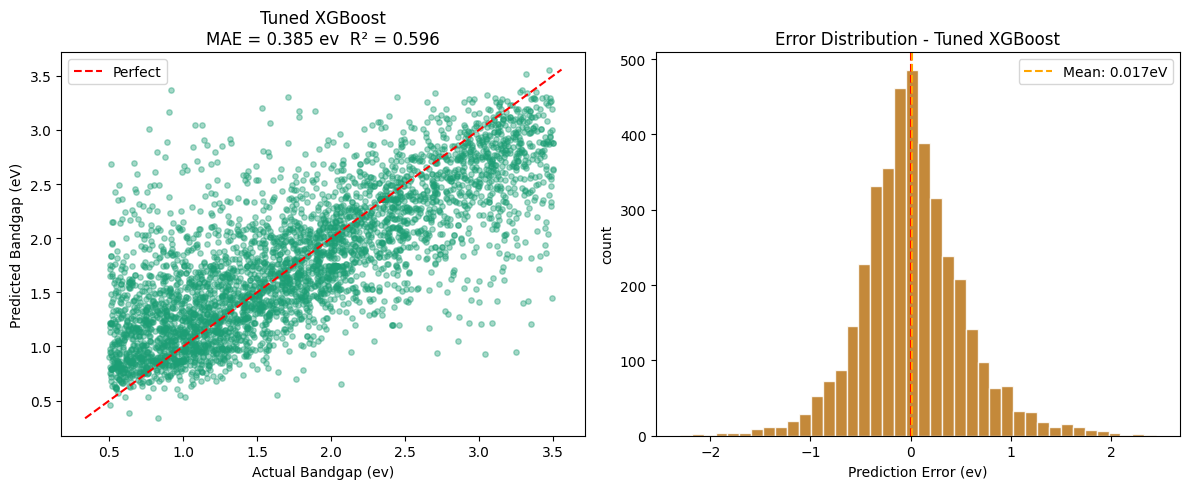

Saved day5_xgb_results.png


In [20]:
xgb_best.fit(X_train,Y_train)
y_pred_best =xgb_best.predict(X_test)
mae_best = mean_absolute_error(Y_test,y_pred_best)
r2_best = xgb_best.score(X_test,Y_test)
fig,axes =plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(Y_test,y_pred_best,alpha=0.4,s=15,color='#1D9E75')
lims=[min(Y_test.min(),y_pred_best.min()),
      max(Y_test.max(),y_pred_best.max())]
axes[0].plot(lims,lims,'r--', linewidth=1.5,label='Perfect')
axes[0].set_xlabel('Actual Bandgap (ev)')
axes[0].set_ylabel('Predicted Bandgap (eV)')
axes[0].set_title(f'Tuned XGBoost\nMAE = {mae_best:.3f} ev  R² = {r2_best:.3f}')
axes[0].legend()
errors =y_pred_best - Y_test
axes[1].hist(errors,bins=40,color='#BA7517',edgecolor='white',alpha=0.85)
axes[1].axvline(0,color='red',linestyle='--',linewidth=1.5)
axes[1].axvline(errors.mean(),color='orange',linestyle='--',label=f'Mean: {errors.mean():.3f}eV')
axes[1].set_xlabel('Prediction Error (ev)')
axes[1].set_ylabel('count')
axes[1].set_title('Error Distribution - Tuned XGBoost')
axes[1].legend()
plt.tight_layout()
plt.savefig('day5_xgb_results.png',dpi=150,bbox_inches='tight')
plt.show()
print("Saved day5_xgb_results.png")

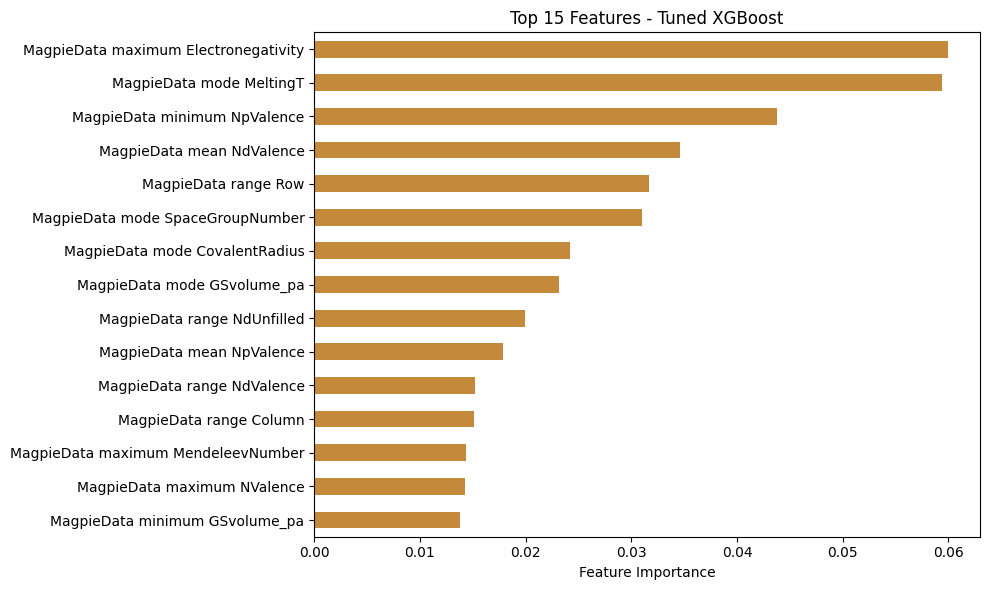

Top 5 XGBoost features:
 MagpieData maximum Electronegativity: 0.0600
 MagpieData mode MeltingT: 0.0594
 MagpieData minimum NpValence: 0.0438
 MagpieData mean NdValence: 0.0346
 MagpieData range Row: 0.0317

Compare with your RF top features from day 4 
do they agree? Agreement = physically meaningful result


In [21]:
import pandas as pd
xgb_importances = pd.Series(
    xgb_best.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)
plt.figure(figsize=(10,6))
xgb_importances.head(15).plot(kind='barh',color='#BA7517',alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Top 15 Features - Tuned XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day5_xgb_importance.png',dpi=150,bbox_inches='tight')
plt.show()
print("Top 5 XGBoost features:")
for feat,imp in xgb_importances.head(5).items():
    print(f" {feat}: {imp:.4f}")
print("\nCompare with your RF top features from day 4 ")
print("do they agree? Agreement = physically meaningful result")

In [26]:
results=pd.DataFrame({
    'Model': [
        'Baseline (predict mean)',
        'Linear Regression',
        'Random Forest (5-CV)',
        'XGBoost default',
        'XGBoost tuned (5-CV)'
    ],
    'MAE (eV)' : [
        '0.6976 eV',
        '0.5876 eV',
        '0.469 ± 0.011 eV',
        f'{mae_xgb:.3f}',
        f'{cv_mae.mean():.3f} ± {cv_mae.std():.3f}'
    ],
    'Notes': [
        'Dumbest possible model',
        'Linear features ->bandgap',
        'Day 4 result',
        'Default params, no tuning',
        'GridSearchCV optimised <- BEST'
    ]
})
print(results.to_string(index=False))
results.to_csv("day5_results_table.csv",index=False)
print("\nSaved day5_results_table.csv")


                  Model         MAE (eV)                          Notes
Baseline (predict mean)        0.6976 eV         Dumbest possible model
      Linear Regression        0.5876 eV      Linear features ->bandgap
   Random Forest (5-CV) 0.469 ± 0.011 eV                   Day 4 result
        XGBoost default            0.398      Default params, no tuning
   XGBoost tuned (5-CV)    0.466 ± 0.010 GridSearchCV optimised <- BEST

Saved day5_results_table.csv
